# Importing Libraries and Reaading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_sas('LLCP2024.XPT')

In [3]:
df.head(10)

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
5,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000006',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
6,1.0,2.0,b'02262024',b'02',b'26',b'2024',1100.0,b'2024000007',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
7,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000008',2.024000e+09,1.0,...,2.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,2.0,1.0,2.0
8,1.0,2.0,b'02202024',b'02',b'20',b'2024',1100.0,b'2024000009',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,1.0
9,1.0,2.0,b'02262024',b'02',b'26',b'2024',1100.0,b'2024000010',2.024000e+09,1.0,...,1.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0


# Filtering Columns and Mapping Them Back

In [4]:
demographic_columns = ['MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME3', 'CHILDREN', '_BMI5', '_URBSTAT', '_IMPRACE', '_AGE_G', 'SEXVAR']

target_column = 'DIABETE4'

In [5]:
df_eda = df[demographic_columns]

In [6]:
df_eda['DIABETE4'] = df['DIABETE4'].copy()

In [7]:
df_eda

,MARITAL,EDUCA,EMPLOY1,INCOME3,CHILDREN,_BMI5,_URBSTAT,_IMPRACE,_AGE_G,SEXVAR,DIABETE4
0,3.0,4.0,7.0,99.0,88.0,2249.0,1.0,1.0,6.0,2.0,3.0
1,1.0,6.0,7.0,11.0,88.0,2583.0,1.0,1.0,6.0,1.0,3.0
2,6.0,5.0,1.0,99.0,88.0,2253.0,1.0,1.0,5.0,1.0,3.0
3,1.0,6.0,7.0,6.0,88.0,2509.0,1.0,1.0,6.0,1.0,3.0
4,5.0,5.0,8.0,3.0,88.0,1977.0,1.0,1.0,4.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
457665,1.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,6.0,1.0,3.0
457666,5.0,2.0,1.0,6.0,88.0,2066.0,NaN,2.0,6.0,1.0,3.0
457667,5.0,6.0,7.0,8.0,88.0,2437.0,NaN,2.0,6.0,1.0,1.0
457668,1.0,5.0,2.0,10.0,88.0,2441.0,NaN,1.0,4.0,1.0,3.0


Semua mapping di bawah diambil langsung dari data dictionary-nya.

In [8]:
marital_map = {
    1: 'Married', 
    2: 'Divorced', 
    3: 'Widowed', 
    4: 'Separated', 
    5: 'Never Married', 
    6: 'Unmarried Couple',
    9: 'Refused'
}

educa_map = {
    1: 'Kindergarten/None', 
    2: 'Elementary', 
    3: 'Some High School', 
    4: 'High School Grad', 
    5: 'Some College', 
    6: 'College Grad',
    9: 'Refused'
}

employ1_map = {
    1: 'Employed', 
    2: 'Self-employed', 
    3: 'Out of work > 1 yr', 
    4: 'Out of work < 1 yr', 
    5: 'Homemaker', 
    6: 'Student', 
    7: 'Retired', 
    8: 'Unable to work',
    9: 'Refused'
}

# need escapes otherwise it will treat it as latex >:(
income3_map = {
    1: '< \$10k', 
    2: '\$10k - \$15k', 
    3: '\$15k - \$20k', 
    4: '\$20k - \$25k', 
    5: '\$25k - \$35k', 
    6: '\$35k - \$50k', 
    7: '\$50k - \$75k', 
    8: '\$75k - \$100k', 
    9: '\$100k - \$150k', 
    10: '\$150k - \$200k', 
    11: '>= \$200k', 
    77: 'Not Sure', 
    99: 'Refused'
}

urbstat_map = {
    1: 'Urban', 
    2: 'Rural'
}

imprace_map = {
    1: 'White', 
    2: 'Black', 
    3: 'Asian', 
    4: 'AI/AN',
    5: 'Hispanic', 
    6: 'Other'
}

diabete4_map = {
    1: 'Diabetes', 
    2: np.nan, 
    3: 'Healthy', 
    4: 'Diabetes', 
    7: np.nan, 
    9: np.nan
}

age_map = {
    1: '18-24',
    2: '25-34',
    3: '35-44',
    4: '45-54',
    5: '55-64',
    6: '65+'
}

sex_map = {
    1: 'Male',
    2: 'Female'
}


df_eda['MARITAL'] = df['MARITAL'].map(marital_map)
df_eda['EDUCA'] = df['EDUCA'].map(educa_map)
df_eda['EMPLOY1'] = df['EMPLOY1'].map(employ1_map)
df_eda['INCOME3'] = df['INCOME3'].map(income3_map)
df_eda['_URBSTAT'] = df['_URBSTAT'].map(urbstat_map)
df_eda['CHILDREN'] = df['CHILDREN'].replace({
    88: 0,
    99: np.nan
})
df_eda['_BMI5'] = df_eda['_BMI5'] / 100
df_eda['_IMPRACE'] = df['_IMPRACE'].map(imprace_map)
df_eda['DIABETE4'] = df['DIABETE4'].map(diabete4_map)
df_eda['_AGE_G'] = df_eda['_AGE_G'].map(age_map)
df_eda['SEXVAR'] = df_eda['SEXVAR'].map(sex_map)

In [9]:
df_eda.head()

,MARITAL,EDUCA,EMPLOY1,INCOME3,CHILDREN,_BMI5,_URBSTAT,_IMPRACE,_AGE_G,SEXVAR,DIABETE4
0,Widowed,High School Grad,Retired,Refused,0.0,22.49,Urban,White,65+,Female,Healthy
1,Married,College Grad,Retired,>= \$200k,0.0,25.83,Urban,White,65+,Male,Healthy
2,Unmarried Couple,Some College,Employed,Refused,0.0,22.53,Urban,White,55-64,Male,Healthy
3,Married,College Grad,Retired,\$35k - \$50k,0.0,25.09,Urban,White,65+,Male,Healthy
4,Never Married,Some College,Unable to work,\$15k - \$20k,0.0,19.77,Urban,White,45-54,Male,Healthy


# Basic statistics and null values handling

In [10]:
df_eda.isna().sum()

MARITAL         9
EDUCA           7
EMPLOY1      3303
INCOME3      9269
CHILDREN     9379
_BMI5       43037
_URBSTAT    14623
_IMPRACE        0
_AGE_G          0
SEXVAR          0
DIABETE4     4429
dtype: int64

Dataset ini memiliki sangat banyak missing values, terutama pada kolom _BMI5. Hal ini mungkin terjadi karena banyak orang yang mungkin merasa bahwa tinggi dan berat badan adalah data yang cukup sensitif. Namun, sepertinya missing values tersebut masih aman untuk langsung didrop dari EDA dikarenakan jumlah sampel dataset ini yang cukup besar, yaitu sekitar 400k+. Mari kita konfirmasi nilai exact dari jumlah sampelnya.

In [11]:
df_eda.shape

(457670, 11)

Bisa dilihat dari nilai pertama bahwa dataset ini memiliki 450k sampel. Setelah penghapusan mungkin berkurang menjadi 390k - 400k. Mari coba langsung lihat hasilnya.

In [12]:
df_eda.dropna(inplace=True)

In [13]:
df_eda.shape

(395780, 11)

Kita memiliki 395k sampel setelah penghapusan semua missing values. Jumlah data yang hilang sebenarnya cukup signifikan, yaitu hampir 9% dari total semua sampel. Hal ini mungkin sebaiknya ditangani dengan imputasi menggunakan mean, modus, atau algoritma yang lebih sophisticated lainnya. Namun, karena tujuan dari EDA ini adalah untuk menganalisis tren yang ada secara high-level (bukan fine grained), sepertinya 395k sampel akan masih sufficient untuk hal ini.   

In [14]:
df_eda.describe()

,CHILDREN,_BMI5
count,395780.000000,395780.000000
mean,0.470223,28.551850
std,1.111298,6.582902
min,0.000000,12.000000
25%,0.000000,24.140000
50%,0.000000,27.440000
75%,0.000000,31.750000
max,83.000000,99.840000


Hal yang menarik di sini adalah bahwa ada keluarga yang sampai memiliki 83 anak. Maka ada kemungkinan bahwa nilai-nilai pada kolom CHILDREN akan menjadi right-skewed. Log-transform dapat digunakan apabila hal tersebut ternyata benar adanya.

In [15]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 395780 entries, 0 to 450352
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   MARITAL   395780 non-null  str    
 1   EDUCA     395780 non-null  str    
 2   EMPLOY1   395780 non-null  str    
 3   INCOME3   395780 non-null  str    
 4   CHILDREN  395780 non-null  float64
 5   _BMI5     395780 non-null  float64
 6   _URBSTAT  395780 non-null  str    
 7   _IMPRACE  395780 non-null  str    
 8   _AGE_G    395780 non-null  str    
 9   SEXVAR    395780 non-null  str    
 10  DIABETE4  395780 non-null  str    
dtypes: float64(2), str(9)
memory usage: 62.9 MB


# EDA

EDA demografik pada notebook ini ditujukan untuk menjawab 2 pertanyaan, yaitu:

1. Variabel demografik apa saja yang cenderung berkorelasi dengan status diabetes?
2. IDF menyebutkan kalau gaya hidup adalah faktor kunci pada diabetes tipe 2 (yang mencakup 90% kasus). Dengan pernyataan tersebut, kita ingin melihat: apakah ada kelompok masyarakat tertentu yang secara statistik memang lebih rentan terkena diabetes?


## EDA Setup

Karena kami menggunakan tema PPT yang gelap, visualisasi dengan background putih polos akan terlihat kurang menyatu (terkesan seperti tempelan screenshot). Oleh karena itu, kami memutuskan untuk mem-plot semua EDA dalam format dark mode dan menyimpannya dengan latar transparan supaya visualisasi ini bisa terlihat bagus nantinya.

In [16]:
df_eda.columns

Index(['MARITAL', 'EDUCA', 'EMPLOY1', 'INCOME3', 'CHILDREN', '_BMI5',
       '_URBSTAT', '_IMPRACE', '_AGE_G', 'SEXVAR', 'DIABETE4'],
      dtype='str')

In [17]:
from pypalettes import load_cmap
%config InlineBackend.figure_format = 'retina'
from qbstyles import mpl_style

neon_cmap = load_cmap('Neon')
neon_colors = np.array(neon_cmap.colors)

blue_orange_cmap = load_cmap("Blue2DarkOrange12Steps")
blue_orange_colors = np.array(blue_orange_cmap.colors)

mpl_style(dark=True)

## Diabetes Distrbution

/tmp/ipykernel_15469/1594455145.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


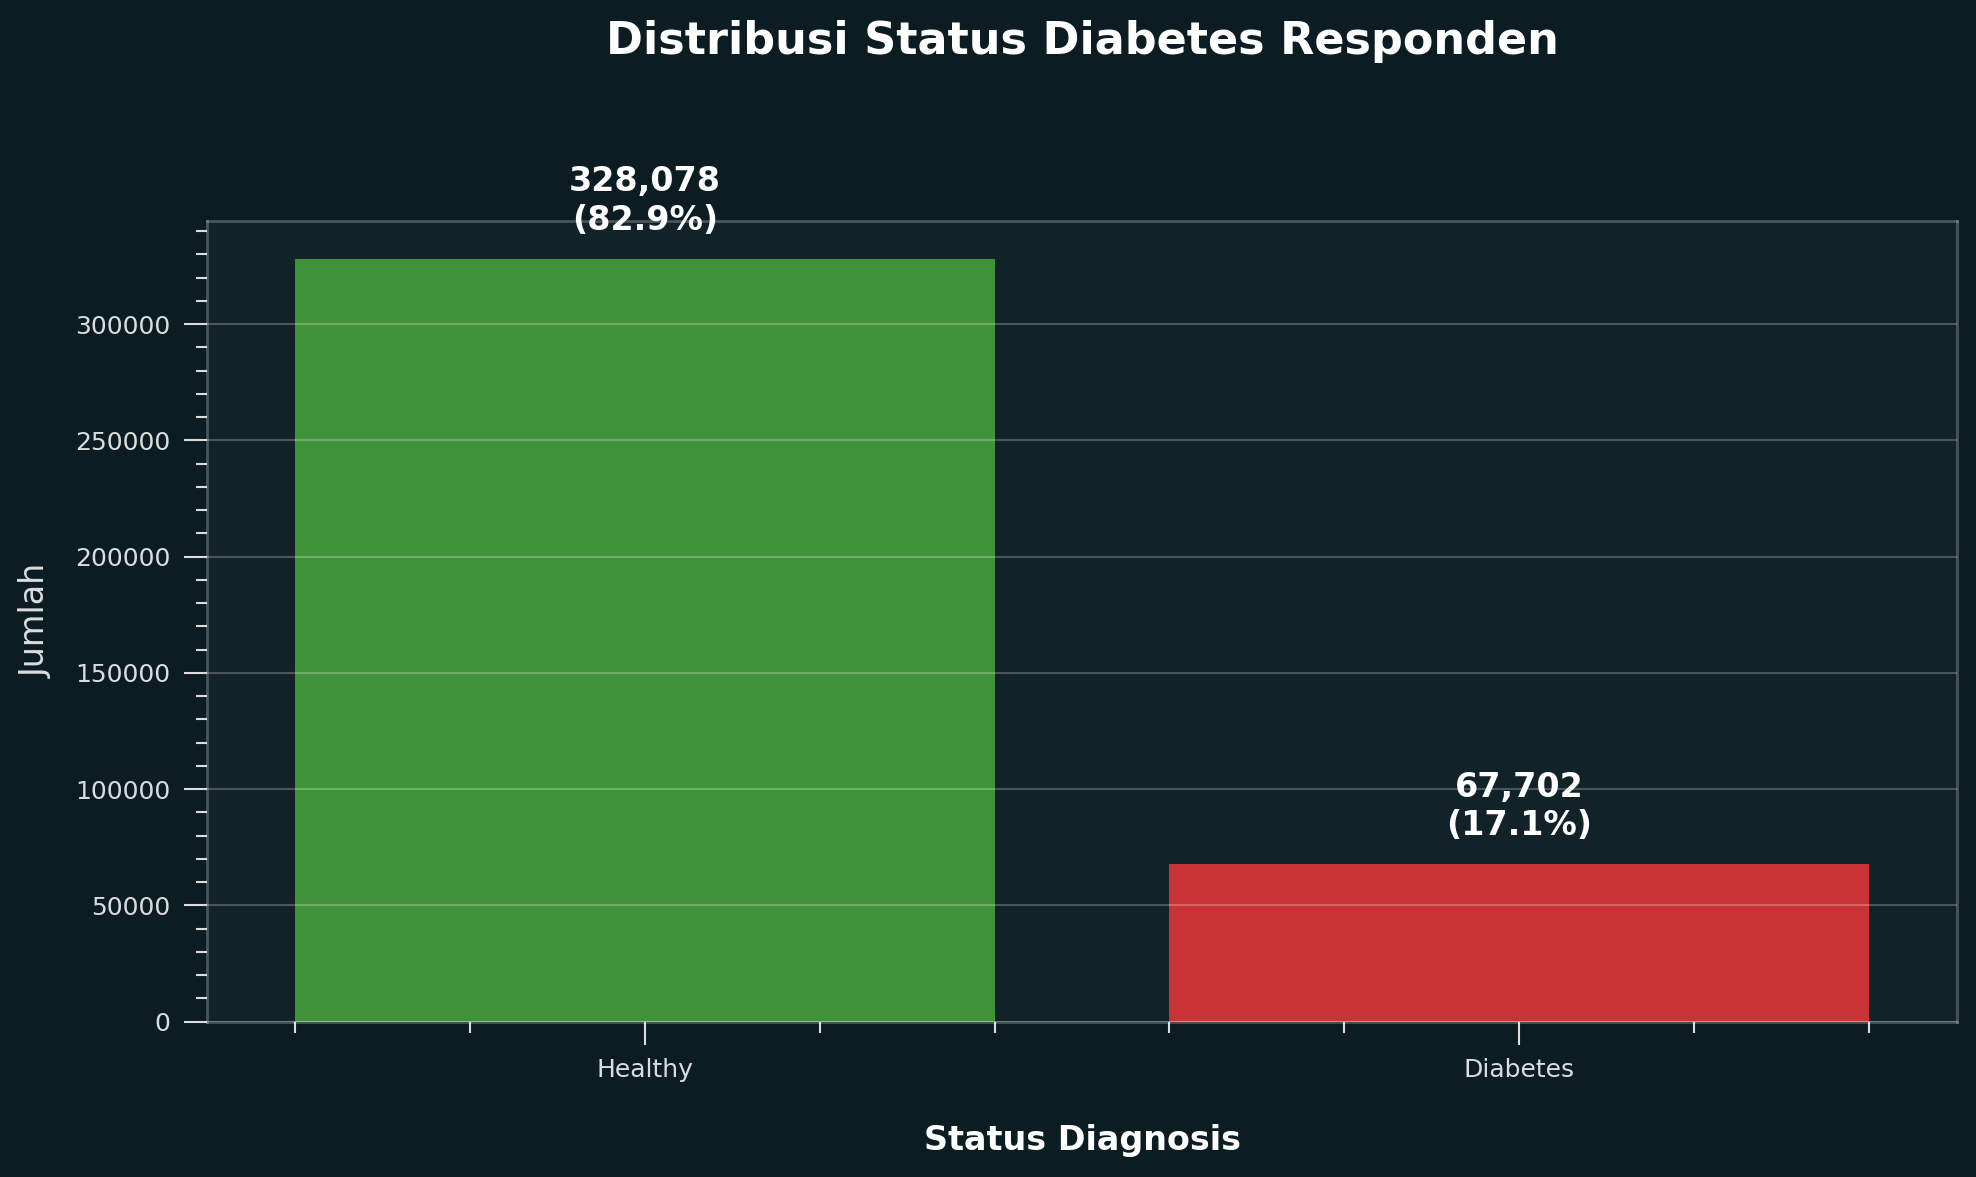

In [20]:
target_counts = df_eda['DIABETE4'].value_counts().reset_index()
target_counts.columns = ['DIABETE4', 'Jumlah']

total_responden = target_counts['Jumlah'].sum()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='DIABETE4', 
    y='Jumlah', 
    data=target_counts,
    palette=['C1', 'C0']
)

for p in ax.patches:
    height = p.get_height()
    persentase = (height / total_responden) * 100
    
    label_text = f"{int(height):,}\n({persentase:.1f}%)"
    
    ax.annotate(label_text, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#FFFFFF',
                xytext=(0, 8), textcoords='offset points')

plt.title('Distribusi Status Diabetes Responden', 
          fontsize=16, weight='bold', pad=60, color='#FFFFFF')
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', labelpad=15, color='#FFFFFF')

plt.tight_layout()

plt.savefig('./outputs/demographic/ar_distribusi_target_ppt.png', transparent=True, dpi=300, bbox_inches='tight')

Terlihat secara jelas bahwa ada data imbalance yang cukup signifikan di sini. Pada dataset ini 83% orang masuk ke kelas healthy, sedangkan hanya 17% yang masuk ke kelas diabetic. Hal ini bisa sangat bermasalah saat proses modelling nanti karena model akan sangat bias ke kelas yang jauh lebih mayoritas di sini. Apabila hasil modelling tidak terlalu bagus, dan recall/precision pada kelas minor jelek, maka harus dipertimbangkan untuk mencoba teknik oversampling pada diabetic atau undersampling pada healthy agar data lebih seimbang.

## Categorical

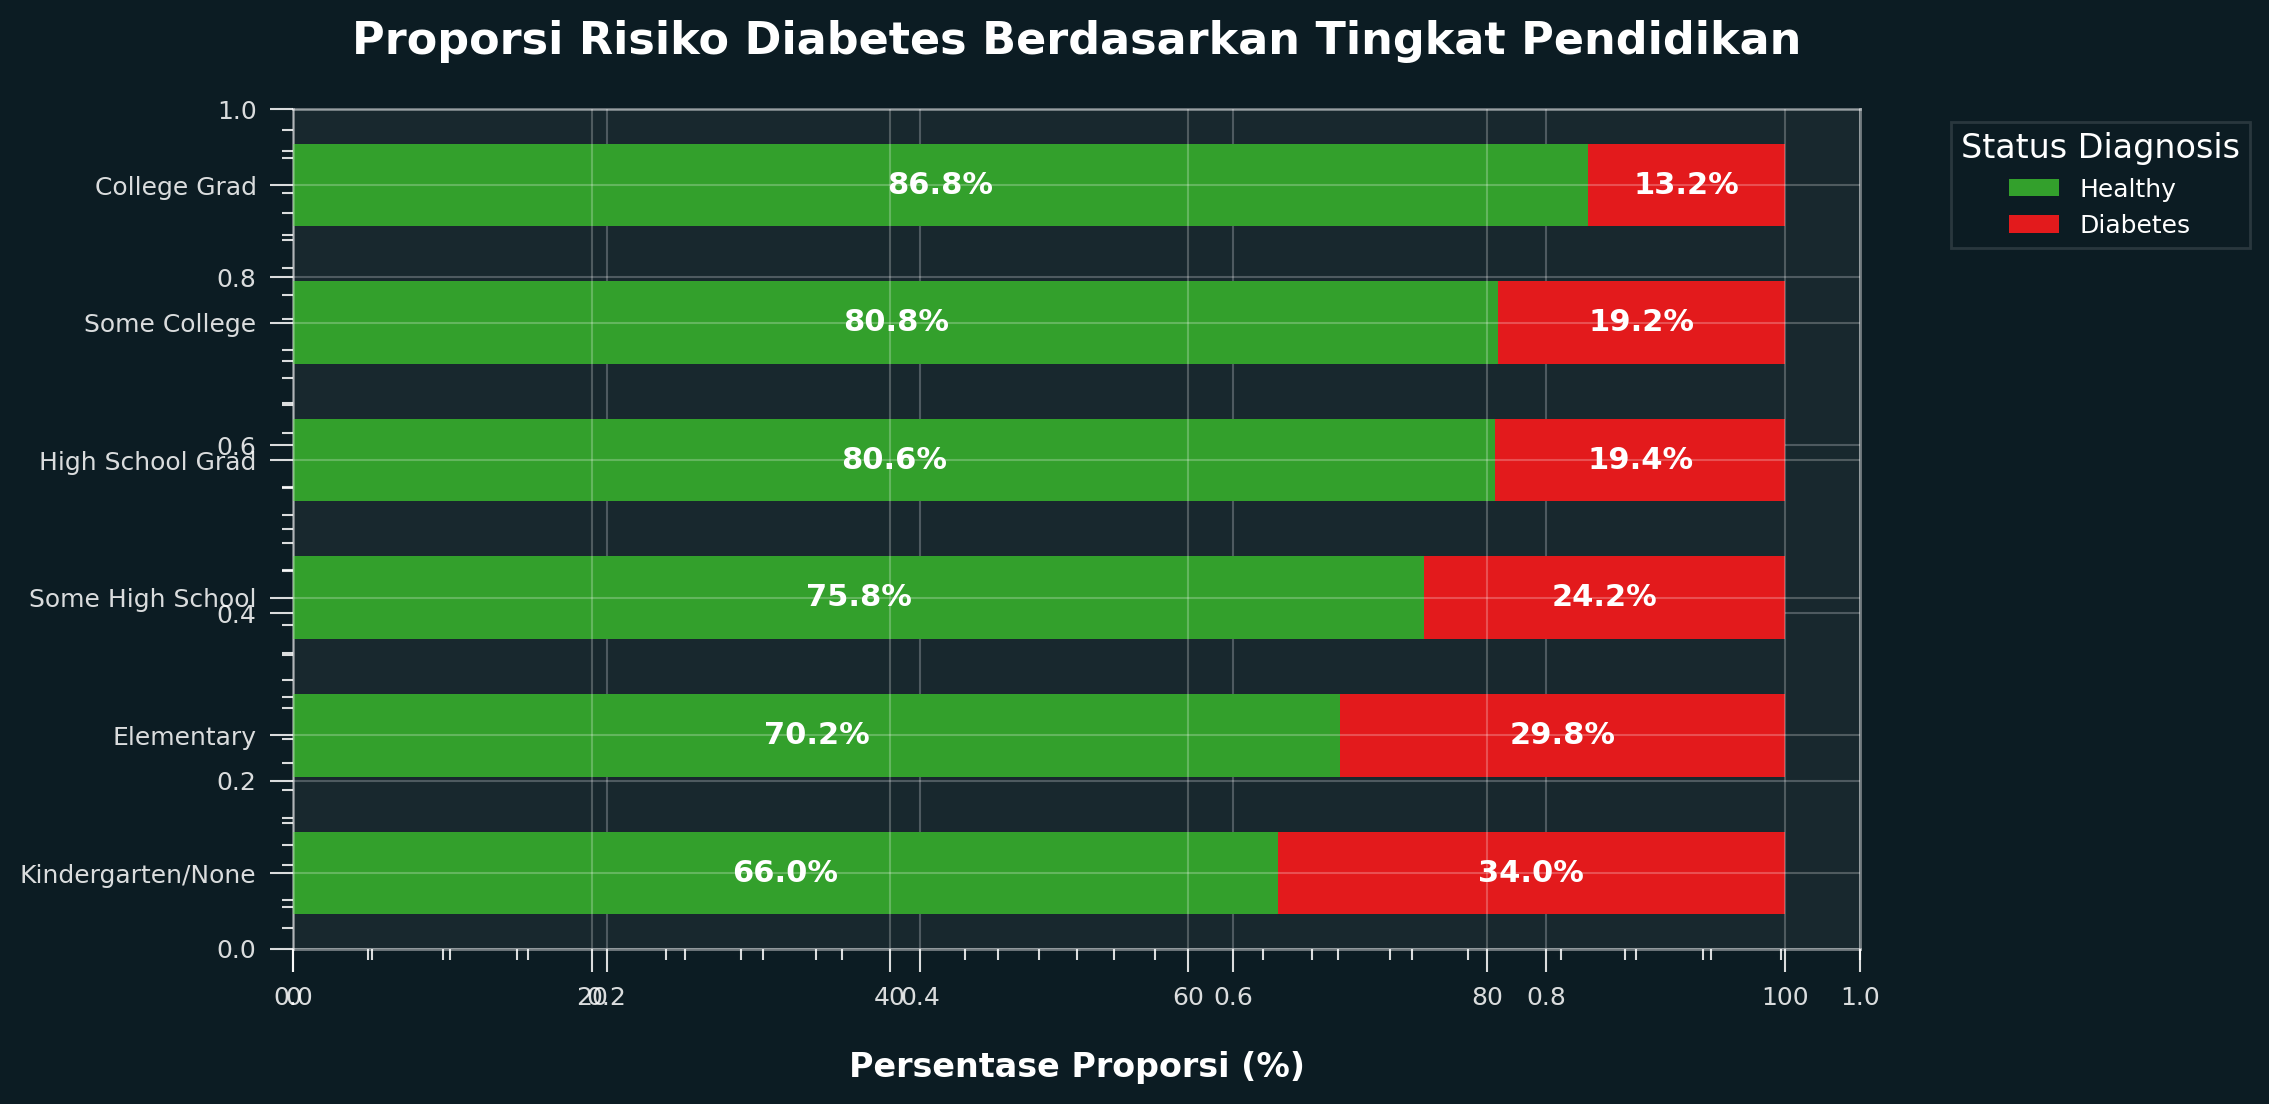

In [34]:
educa_order = ['Kindergarten/None', 'Elementary', 'Some High School', 
               'High School Grad', 'Some College', 'College Grad']

df_plot = df_eda[df_eda['EDUCA'].isin(educa_order)].copy()

crosstab_educa = pd.crosstab(df_plot['EDUCA'], df_plot['DIABETE4'], normalize='index') * 100

crosstab_educa = crosstab_educa.reindex(educa_order)


kategori_target = ['Healthy','Diabetes'] 
crosstab_educa = crosstab_educa[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_educa.plot(kind='barh', stacked=True, color=['C1', 'C0'], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Tingkat Pendidikan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)


plt.tight_layout()

plt.savefig('./outputs/demographic/bivariat_pendidikan_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()



Terlihat ada tren linear yang sangat jelas di sini dimana tingkat edukasi yang lebih rendah memiliki proporsi diabetes yang lebih tinggi. Hal ini harus diinvestigasi lebih lanjut dengan menggabung pada lifestyle untuk melihat apakah mungkin ada korelasi dengan diet yang buruk, BMI yang tinggi, atau faktor lainnya. 

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '

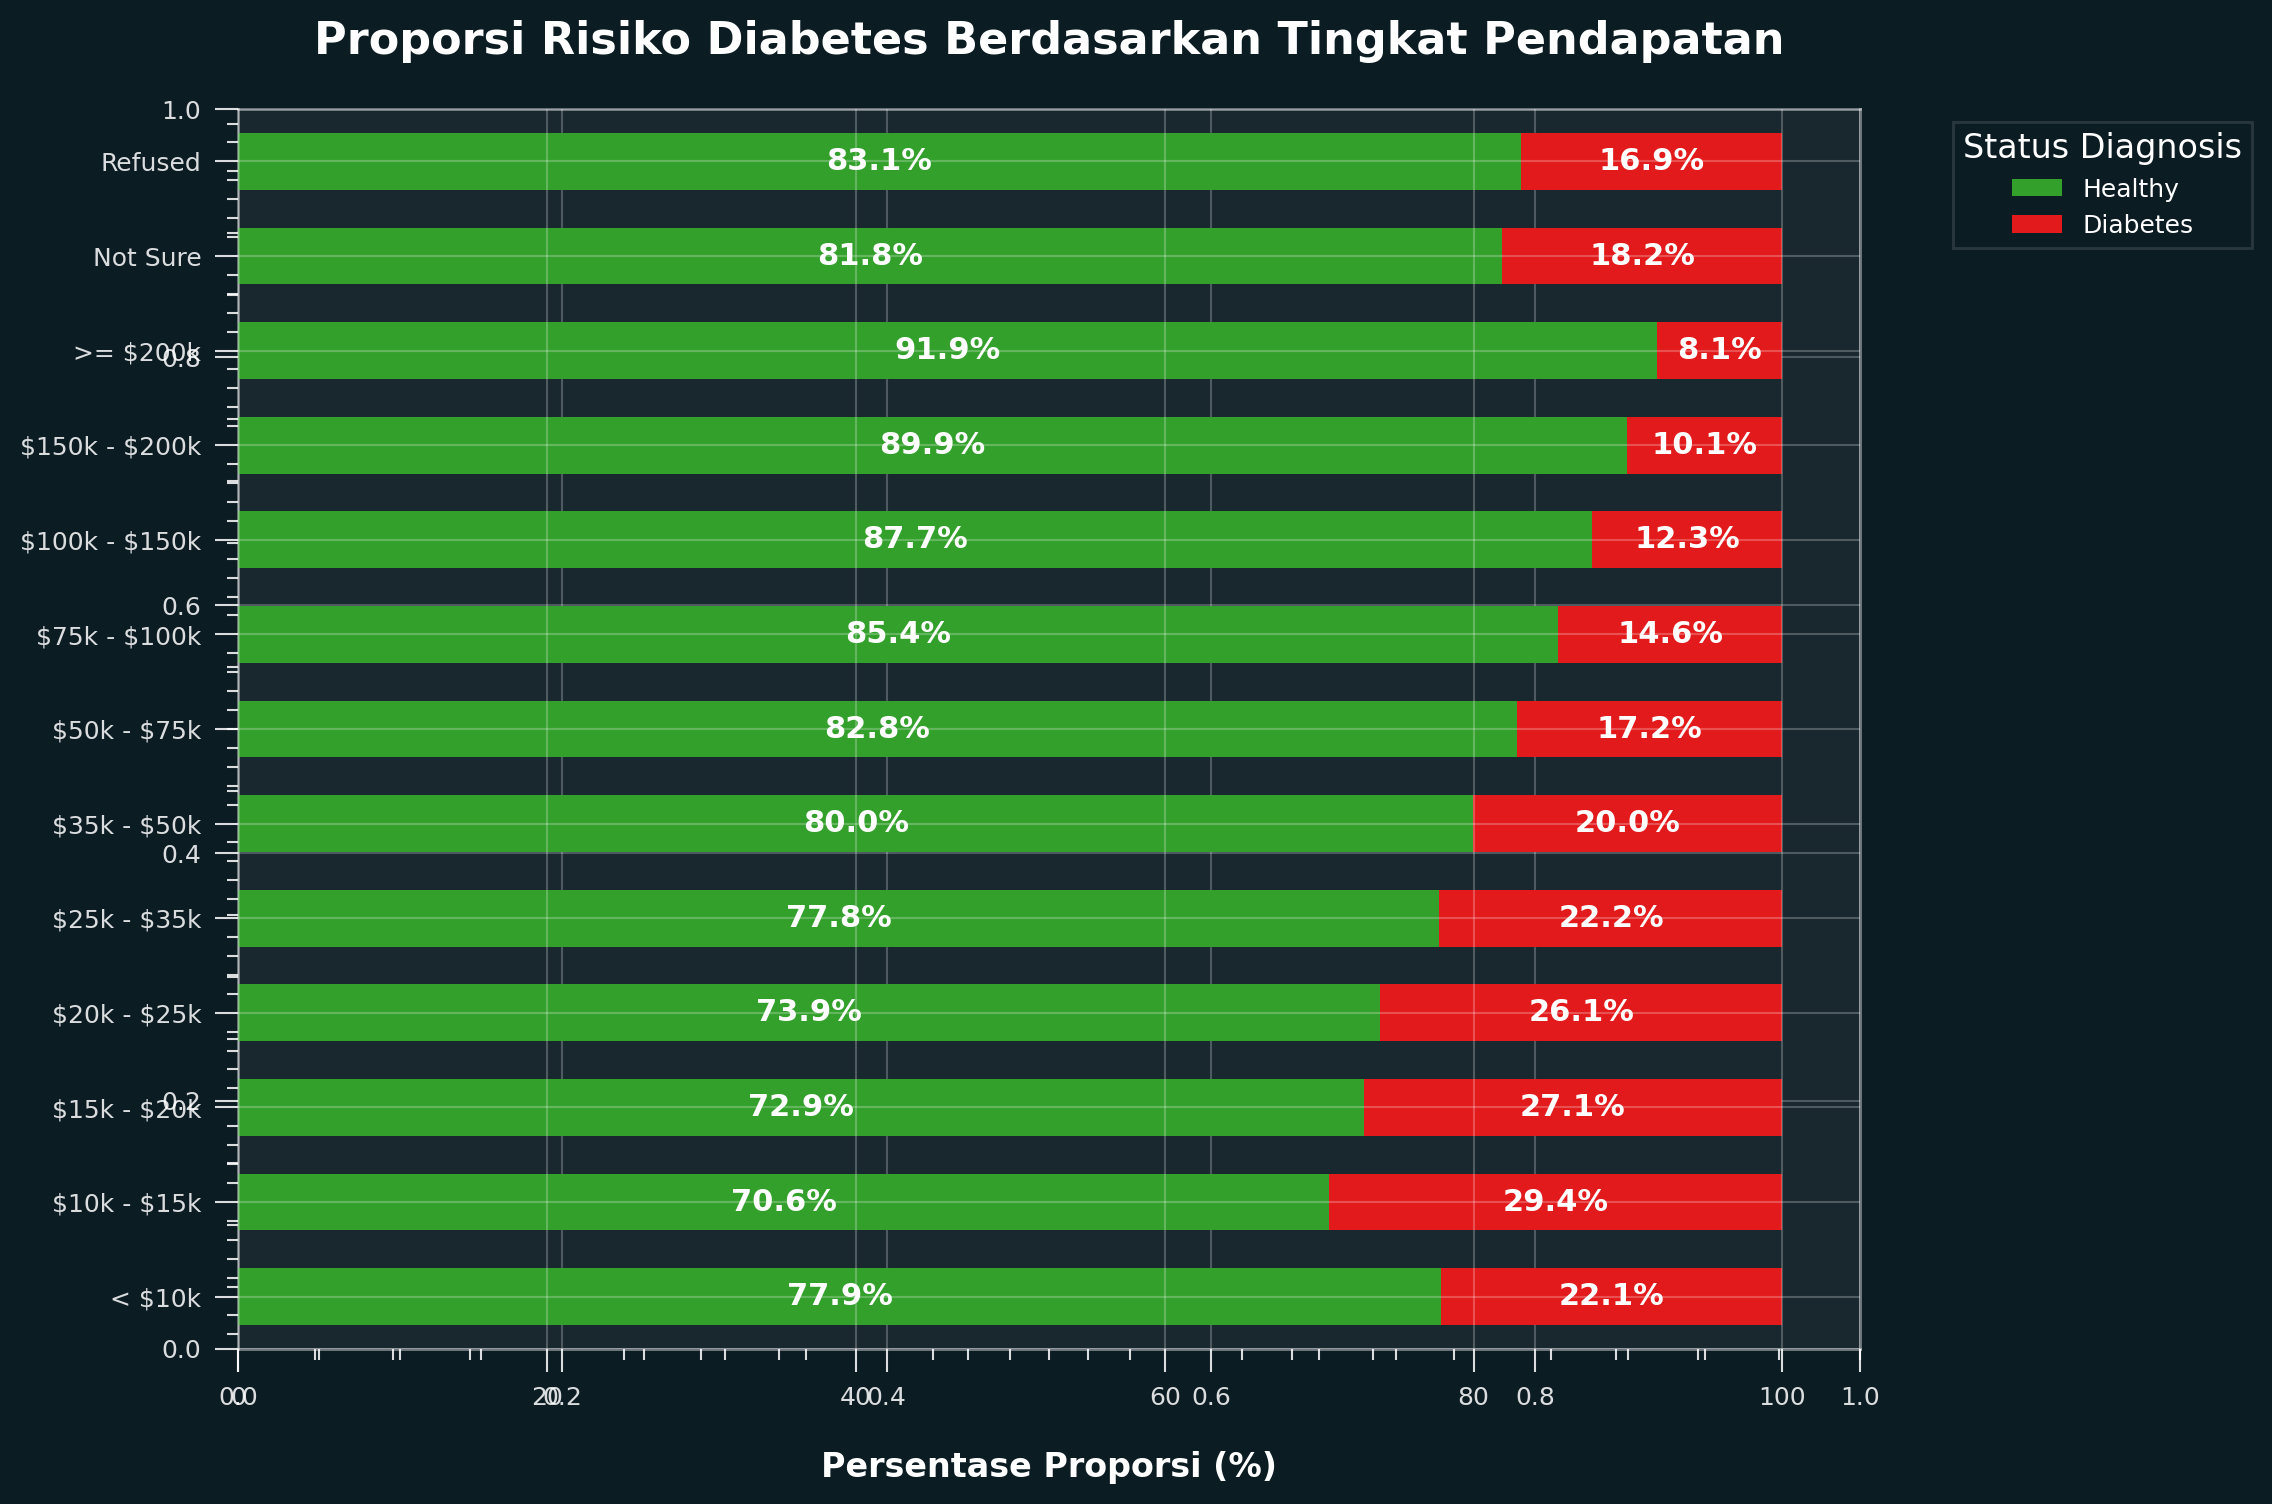

In [35]:
income_order = [
    '< \$10k', 
    '\$10k - \$15k', 
    '\$15k - \$20k', 
    '\$20k - \$25k', 
    '\$25k - \$35k', 
    '\$35k - \$50k', 
    '\$50k - \$75k', 
    '\$75k - \$100k', 
    '\$100k - \$150k', 
    '\$150k - \$200k', 
    '>= \$200k', 
    'Not Sure', 
    'Refused'
]

df_plot_inc = df_eda[df_eda['INCOME3'].isin(income_order)].copy()

crosstab_income = pd.crosstab(df_plot_inc['INCOME3'], df_plot_inc['DIABETE4'], normalize='index') * 100
crosstab_income = crosstab_income.reindex(income_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_income = crosstab_income[kategori_target]

fig, ax = plt.subplots(figsize=(12, 8))

crosstab_income.plot(kind='barh', stacked=True, color=['C1', 'C0'], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Tingkat Pendapatan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

# ax.get_xaxis().set_visible(False)
plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_pendapatan_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Memiliki tren linear yang mirip seperti tingkat pendidikan. Semakin rendah incomenya, maka semakin tinggi juga resiko terkena diabetesnya. Hal ini kemungkinan terjadi diakibatkan semakin sedikitnya opsi untuk memilih makanan yang lebih tinggi nutrisi serta kurangnya literatur terhadap gaya hidup sehat.

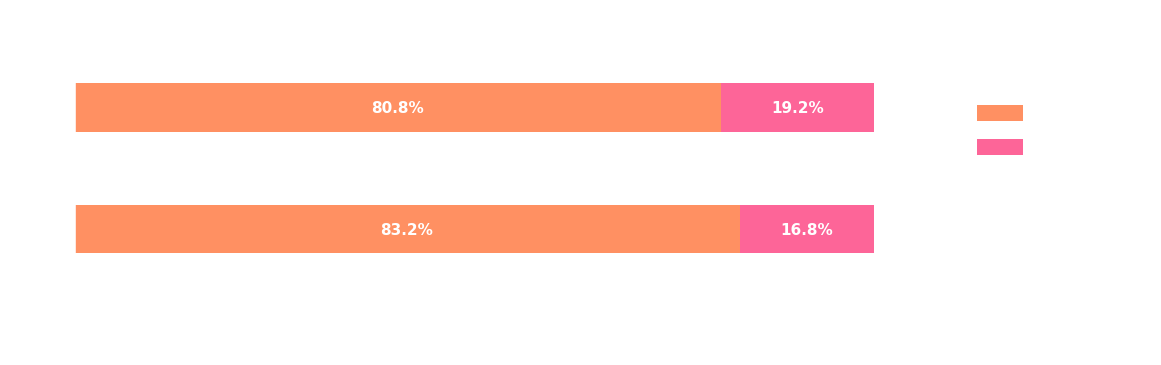

In [21]:
urban_order = ['Urban', 'Rural']

df_plot_urb = df_eda[df_eda['_URBSTAT'].isin(urban_order)].copy()

crosstab_urban = pd.crosstab(df_plot_urb['_URBSTAT'], df_plot_urb['DIABETE4'], normalize='index') * 100
crosstab_urban = crosstab_urban.reindex(urban_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_urban = crosstab_urban[kategori_target]

fig, ax = plt.subplots(figsize=(12, 4))

crosstab_urban.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.4)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Wilayah (Urban vs Rural)', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_urban_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Menariknya, walaupun ada korelasi yang kuat pada income dan education, namun tidak ada korelasi yang sangat kuat pada wilayah urban dibanding wilayah rural. Hal ini mungkin terjadi karena wilayah rural pada America pun masih bisa tergolong wilayah yang maju secara ekonomi dan edukasi sehingga tidak ada perbedaan yang signifikan.

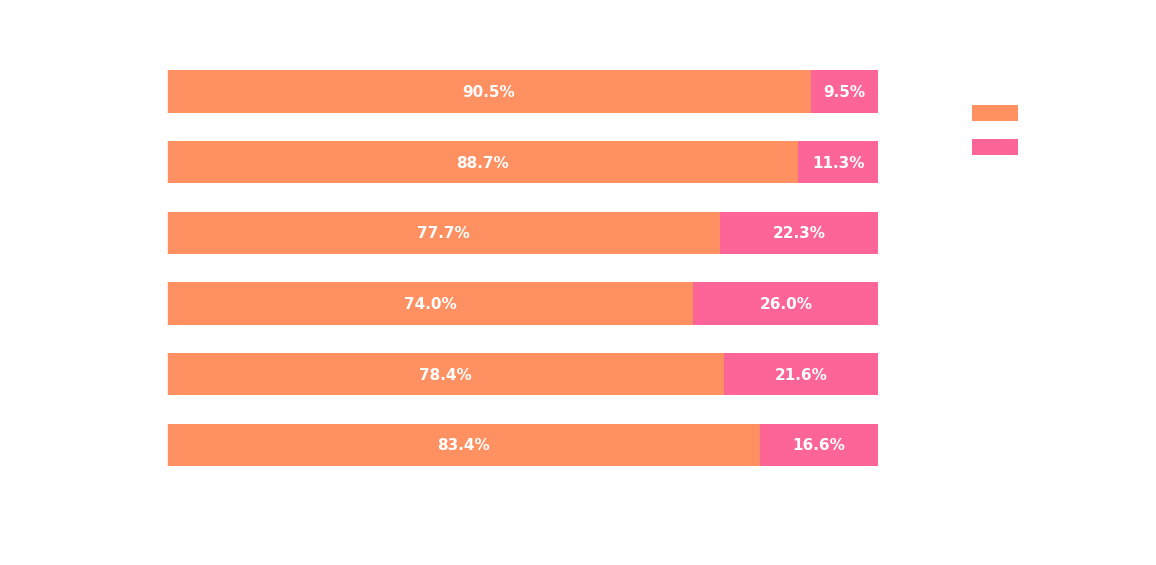

In [22]:
marital_order = ['Married', 'Divorced', 'Widowed', 'Separated', 'Never Married', 'Unmarried Couple']

df_plot_marital = df_eda[df_eda['MARITAL'].isin(marital_order)].copy()

crosstab_marital = pd.crosstab(df_plot_marital['MARITAL'], df_plot_marital['DIABETE4'], normalize='index') * 100
crosstab_marital = crosstab_marital.reindex(marital_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_marital = crosstab_marital[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_marital.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Status Pernikahan', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_marital_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Ini adalah insight yang sangat menarik dimana mereka yang berada di fase perpisahan setelah pernikahan (widowed, separated, divorced) memiliki resiko terrkena diabetes yang tinggi. Saya hanya bisa berasumsi mungkin ini terjadi karena sedikit ada hubungannya dengan mental health. Hal ini nantinya bisa dianalisis lebih lanjut dengan EDA behavioral untuk menemukan korelasi behavioral apa yang menyebabkan hal ini terjadi.

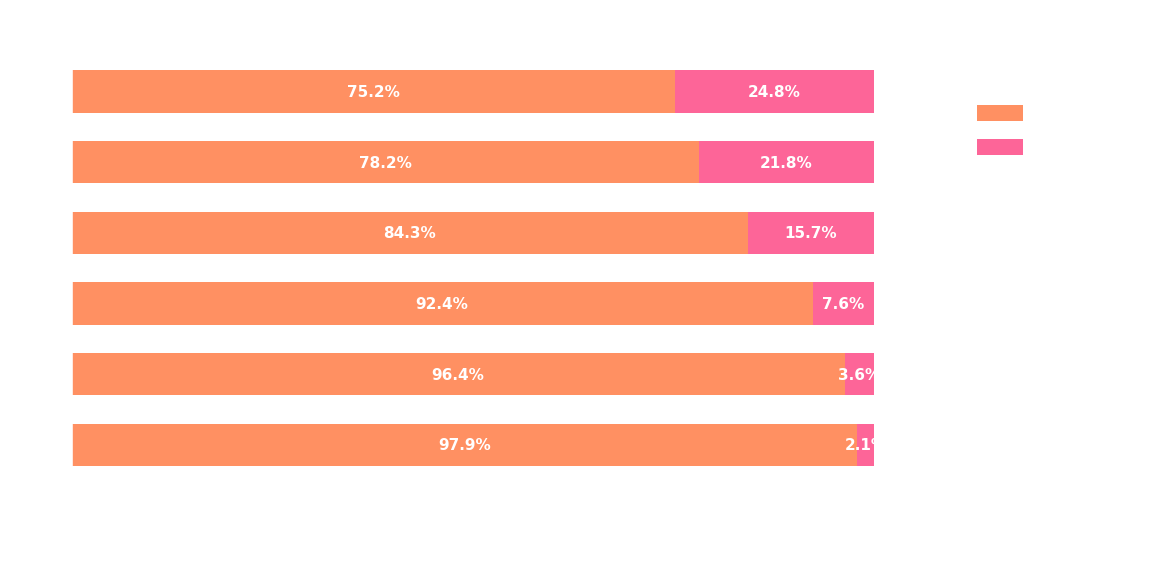

In [23]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_plot_age = df_eda[df_eda['_AGE_G'].isin(age_order)].copy()

crosstab_age = pd.crosstab(df_plot_age['_AGE_G'], df_plot_age['DIABETE4'], normalize='index') * 100
crosstab_age = crosstab_age.reindex(age_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_age = crosstab_age[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_age.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    x = p.get_x() + (width / 2)
    y = p.get_y() + (p.get_height() / 2)
    ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Kelompok Usia', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_age_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Ada tren yang sangat linier dimana semakin tua umur maka semakin tinggi juga resiko terkena diabetesnya. Hal ini bisa terjadi antara halangan untuk melakukan lifestyle yang lebih baik (mungkin kurangnya exercise) atau karena alasan medis yang lebih kompleks.

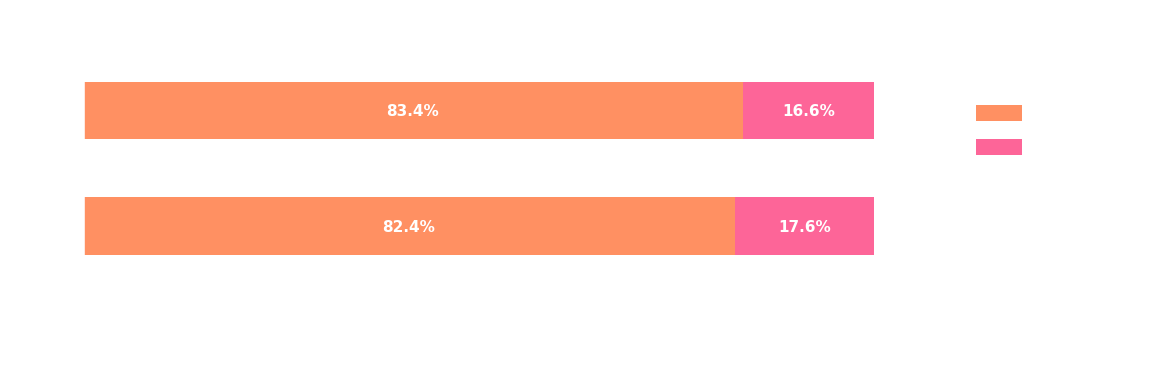

In [24]:
sex_order = ['Male', 'Female']
df_plot_sex = df_eda[df_eda['SEXVAR'].isin(sex_order)].copy()

crosstab_sex = pd.crosstab(df_plot_sex['SEXVAR'], df_plot_sex['DIABETE4'], normalize='index') * 100
crosstab_sex = crosstab_sex.reindex(sex_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_sex = crosstab_sex[kategori_target]

fig, ax = plt.subplots(figsize=(12, 4))

crosstab_sex.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.5)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Jenis Kelamin', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_sex_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Terlihat bahwa proporsinya hampir sama untuk Female dan Male, sehingga insightnya adalah perbedaan gender tidak memiliki korelasi dengan resiko diabetes.

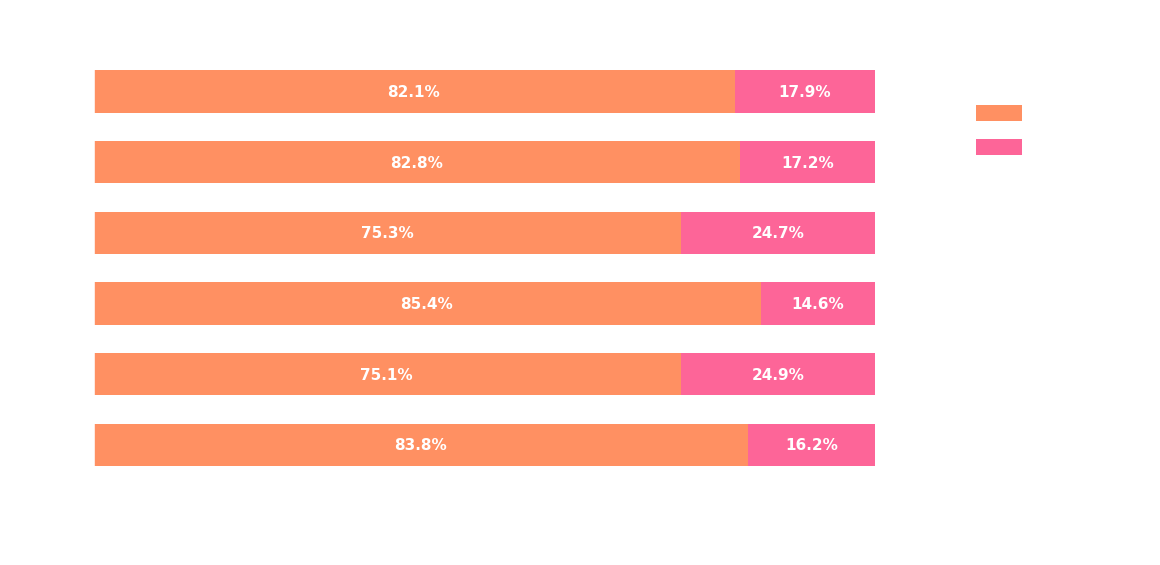

In [25]:
race_order = ['White', 'Black', 'Asian', 'AI/AN', 'Hispanic', 'Other']

df_plot_race = df_eda[df_eda['_IMPRACE'].isin(race_order)].copy()

crosstab_race = pd.crosstab(df_plot_race['_IMPRACE'], df_plot_race['DIABETE4'], normalize='index') * 100
crosstab_race = crosstab_race.reindex(race_order)

kategori_target = ['Healthy', 'Diabetes'] 
crosstab_race = crosstab_race[kategori_target]

fig, ax = plt.subplots(figsize=(12, 6))

crosstab_race.plot(kind='barh', stacked=True, color=neon_colors[:3], ax=ax, width=0.6)

for p in ax.patches:
    width = p.get_width()
    if width > 3: 
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=11)

plt.title('Proporsi Risiko Diabetes Berdasarkan Ras/Etnis', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Persentase Proporsi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('') 

plt.legend(title='Status Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_ras_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Insight ini sangat menarik karena langsung menjawab pertanyaan bisnis kedua tentang kelompok masyarakat yang paling berisiko diabetes. Ke depannya, ini perlu dianalisis lebih dalam: apakah risiko pada ras tertentu memang dipengaruhi oleh faktor demografis atau behavioral, atau justru ada alasan genetik medis yang lebih kompleks di baliknya.

## Numerical

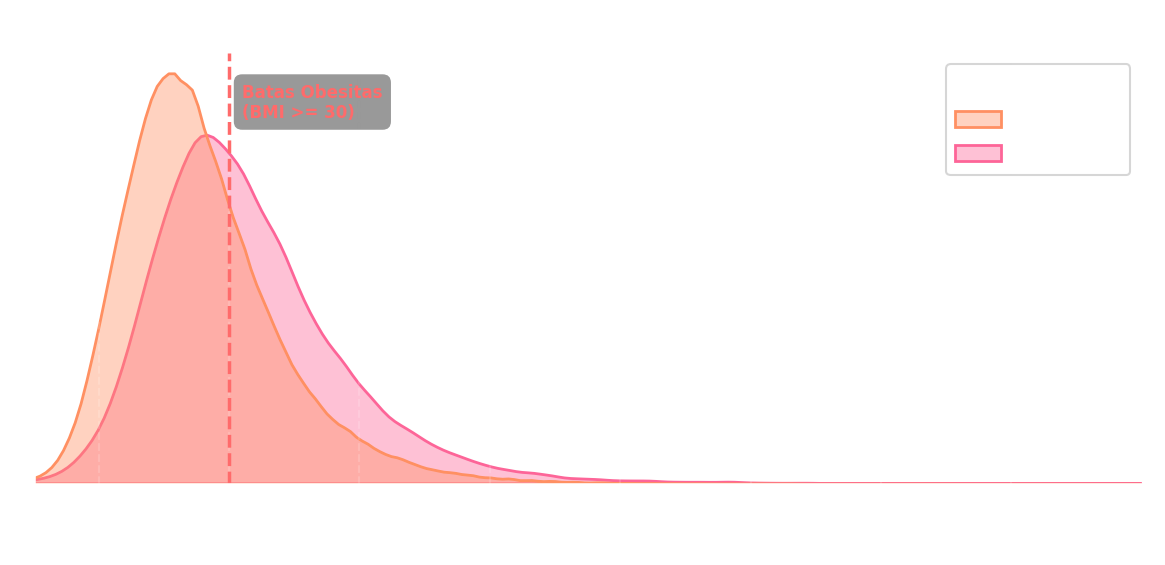

In [86]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=df_eda, 
    x='_BMI5', 
    hue='DIABETE4', 
    fill=True, 
    common_norm=False, 
    palette=neon_colors[:df_eda['DIABETE4'].nunique()],
    alpha=0.4,
    linewidth=2,
    ax=ax
)

plt.title('Pergeseran Kepadatan BMI: Sehat vs Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Kepadatan Populasi', fontsize=12, weight='bold', color='#FFFFFF')

plt.axvline(x=30, color='#FF6B6B', linestyle='--', linewidth=2.5)

y_max = ax.get_ylim()[1]
ax.text(
    x=31,
    y=y_max * 0.85,
    s='Batas Obesitas\n(BMI >= 30)',
    color='#FF6B6B', 
    fontsize=12, 
    weight='bold',
    bbox=dict(facecolor='#000000', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.5')
)

ax.set_yticks([])
ax.set_xlim(15, 100)
ax.grid(True, axis='x', color='#FFFFFF', alpha=0.15, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_kde_grid_ppt_2.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Terlihat adanya pergeseran persebaran data yang cukup signifikan pada KDE plot ini. Sampel yang memiliki mengidap atau beresiko diabetes cenderung memiliki BMI yang lebih tinggi dibanding mereka yang sehat. Mari selanjutnya lakukan visualiasi boxplot untuk mengenal distribusinya lebih jauh.

/tmp/ipykernel_17503/3858528051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


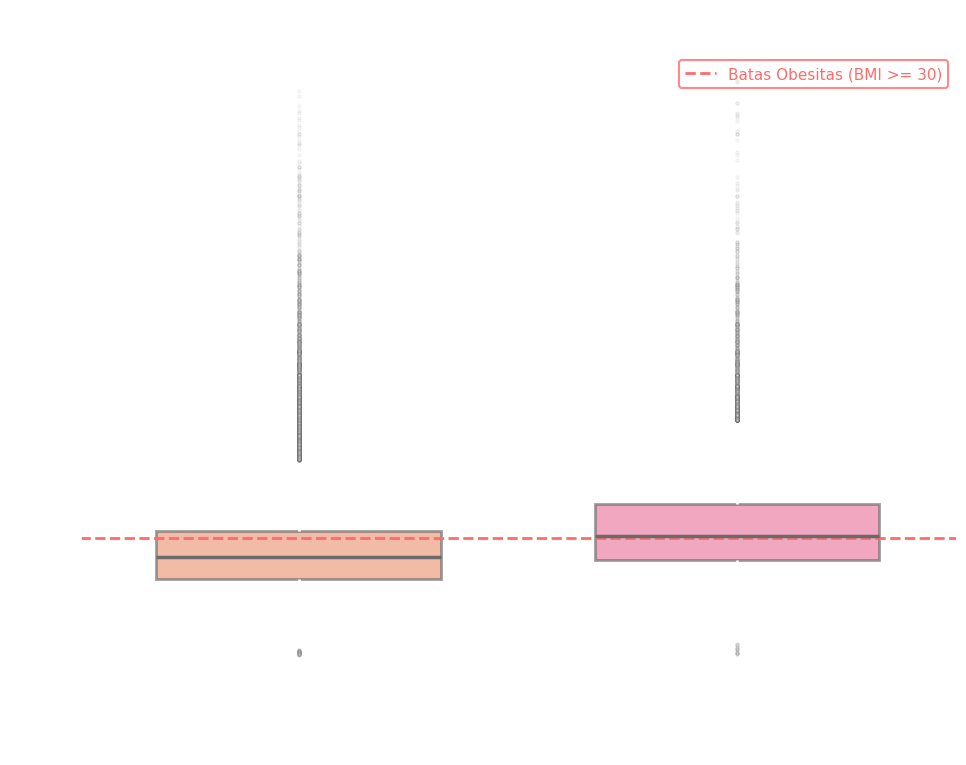

In [64]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=df_eda,
    x='DIABETE4',
    y='_BMI5',
    palette=neon_colors[:2],
    width=0.65,
    linewidth=2,
    boxprops=dict(alpha=0.65), 
    medianprops=dict(linewidth=2.5),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.1, "markerfacecolor": "white"},
    ax=ax
)

plt.title('Distribusi BMI Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF')

plt.axhline(y=30, color='#FF6B6B', linestyle='--', linewidth=2, label='Batas Obesitas (BMI >= 30)')

plt.legend(
    facecolor='none', 
    edgecolor='#FF6B6B', 
    labelcolor='#FF6B6B',
    loc='upper right',
    fontsize=11
)

ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_bmi_diabetes_boxplot_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Dengan distribusi boxplot dapat dilihat bahwa IQR dan median BMI dari mereka yang mengidap diabetes memang cenderung lebih tinggi daripada yang sehat.

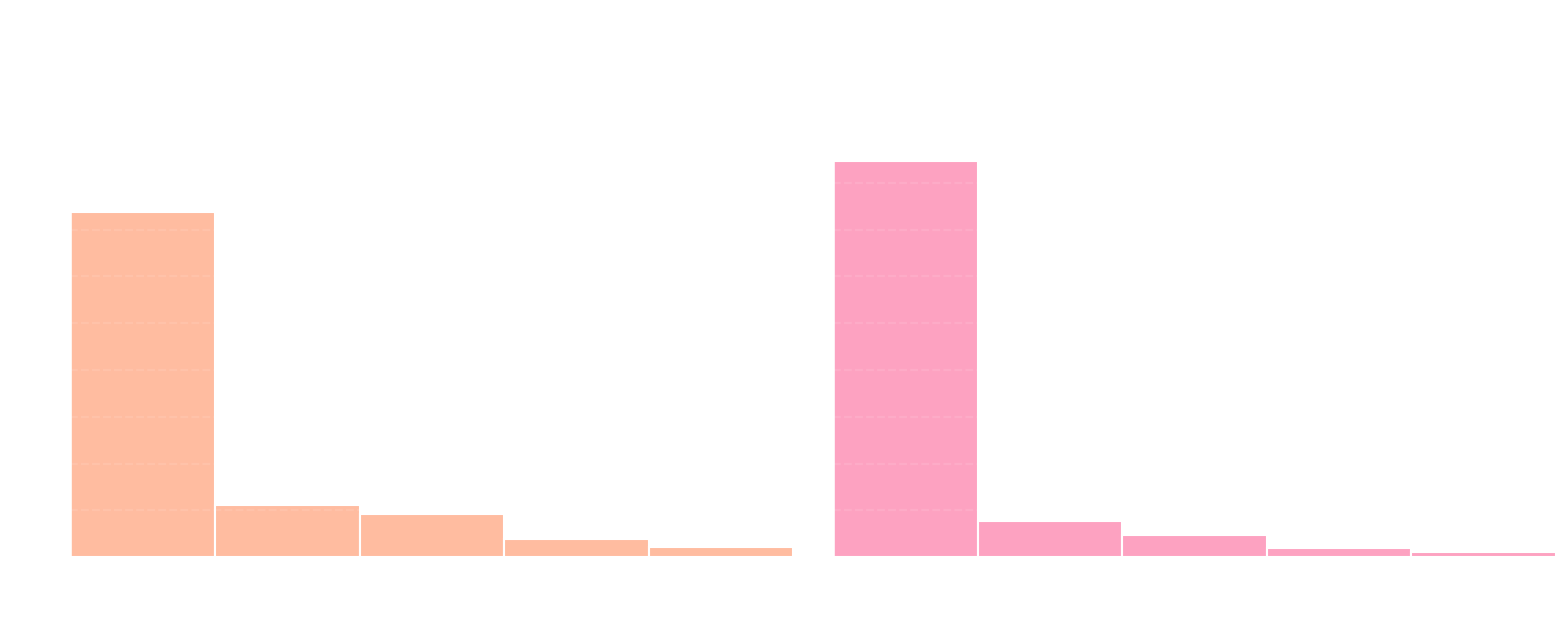

In [80]:
df_child = df_eda.copy()
df_child['CHILDREN_PLOT'] = df_plot['CHILDREN'].clip(upper=4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.histplot(
    data=df_child[df_child['DIABETE4'] == 'Healthy'], 
    x='CHILDREN_PLOT', 
    stat='percent', 
    discrete=True,
    color=neon_colors[0],
    alpha=0.6,
    edgecolor='#FFFFFF',
    ax=ax1
)
ax1.set_title('Distribusi Kelompok: Healthy', fontsize=14, weight='bold', color='#FFFFFF')
ax1.set_xlabel('Jumlah Anak', fontsize=12, color='#FFFFFF')
ax1.set_ylabel('Persentase Populasi (%)', fontsize=12, color='#FFFFFF')

sns.histplot(
    data=df_child[df_child['DIABETE4'] == 'Diabetes'], 
    x='CHILDREN_PLOT', 
    stat='percent', 
    discrete=True,
    color=neon_colors[1],
    alpha=0.6,
    edgecolor='#FFFFFF',
    ax=ax2
)
ax2.set_title('Distribusi Kelompok: Diabetes', fontsize=14, weight='bold', color='#FFFFFF')
ax2.set_xlabel('Jumlah Anak', fontsize=12, color='#FFFFFF')
ax2.set_ylabel('') 

for ax in [ax1, ax2]:
    ax.set_xlim(-0.5, 4.5)
    ax.set_xticks(range(0, 5))
    ax.set_xticklabels(['0', '1', '2', '3', '4+'], color='#FFFFFF')
    ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')


plt.suptitle('Perbandingan Distribusi Jumlah Anak (Agregasi 4+)', 
             fontsize=18, weight='bold', color='#FFFFFF', y=1.05)

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_children_sidebyside_agregasi.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Pada visualisasi histogram children saya lakukan clipping untuk keluarga yang memiliki lebih dari 4 anak dikarenakan adanya indikasi outlier yang cukup signifikan yang kita temukan di awal. Bisa dilihat disini ada sedikit perbedaan distribusi di mana keluarga yang cenderung tidak memiliki anak (dengan kata lain, individual) memiliki proporsi diabetes yang sedikit lebih tinggi daripada kelompok sehat.

/tmp/ipykernel_17503/68780764.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


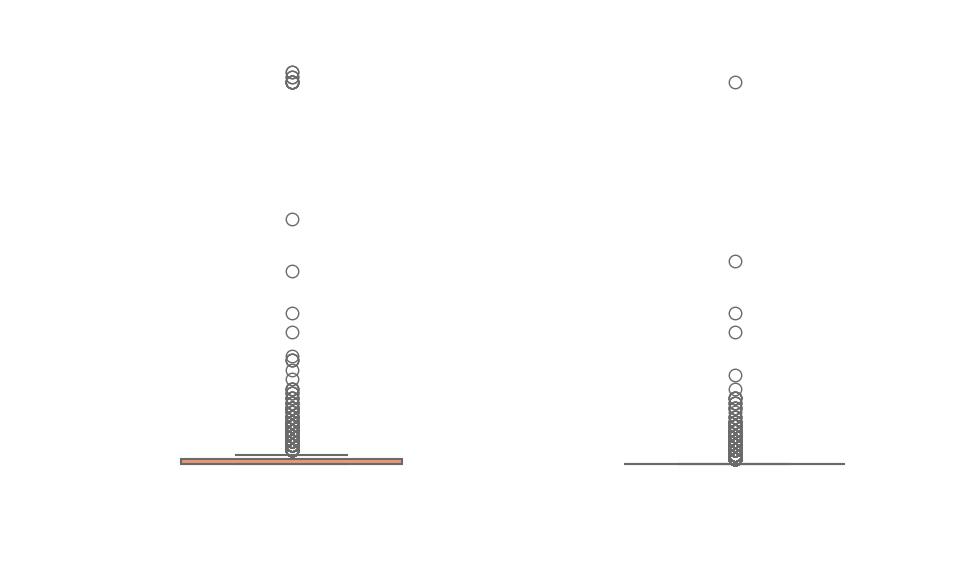

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_eda,
    x='DIABETE4',
    y='CHILDREN',
    palette=neon_colors[:2],
    width=0.5,
    linewidth=1.5,
    ax=ax
)

plt.title('Distribusi Jumlah Anak Berdasarkan Status Diabetes', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=20)
plt.xlabel('Status Diagnosis', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Jumlah Anak', fontsize=12, weight='bold', color='#FFFFFF')

ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/demographic/bivariat_children_boxen_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

Analisis boxplot di sini cenderung tidak memberikan insight baru dikarenakan datanya yang bersifat diskrit dan memiliki range yang cukup rendah (kebanyakan data terletak di antara 0-4). Boxplot di sini lebih cocok untuk analisis modelling, di mana kita bisa melihat ada outlier yang sangat ekstrim. Selanjutnya bisa dilakukan analsisis bagaimana jumlah dari outlier tersebut dan dilihat apakah harus dilakukan imputasi atau drop saja. Hal ini akan dibahas lebih lanjut pada EDA modelling.

## Deep dive race demographics comparison

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_17503/2328539582.py:1: SyntaxWarning: invalid escape sequence '\$'
  low_income_labels = ['< \$10k', '\$10k - \$15k', '\$15k - \$20k', '\$20k - \$25k']
/tmp/ipykernel_17503/2328539582

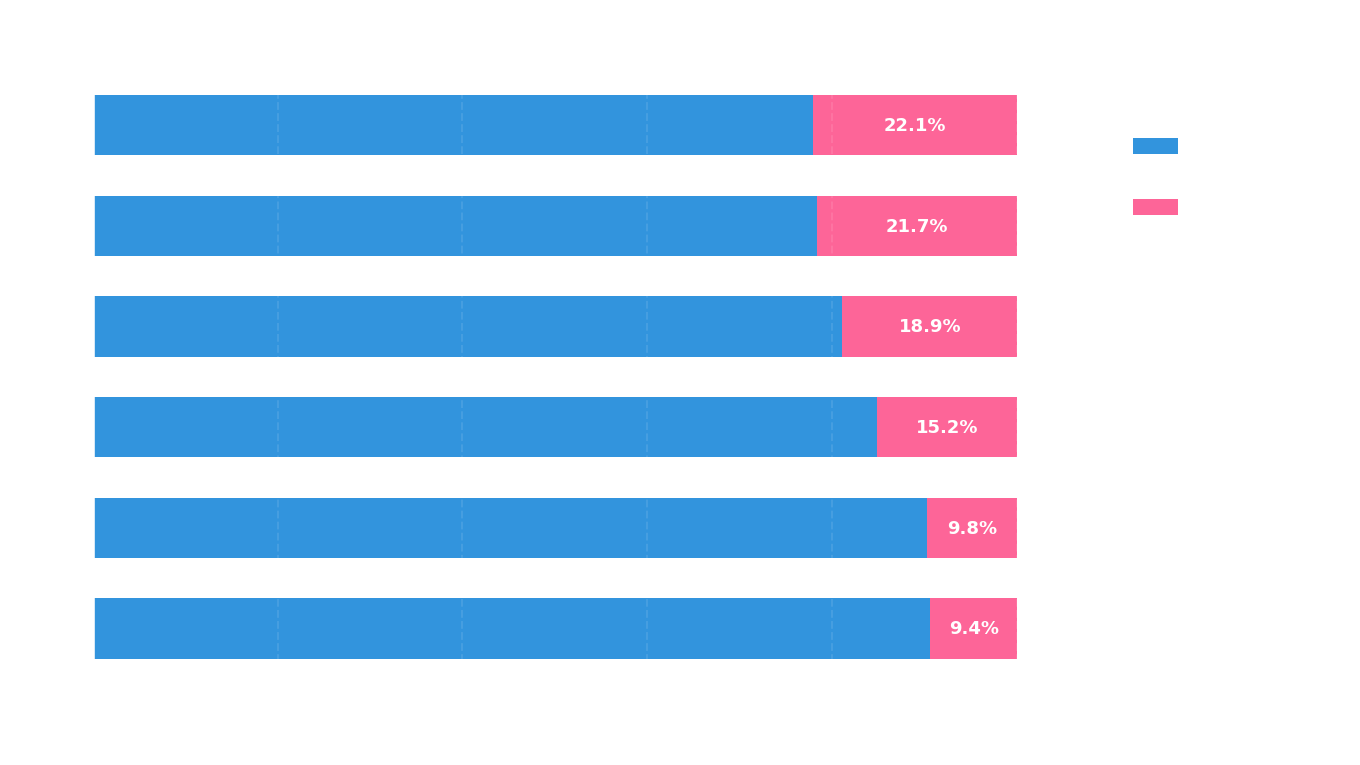

In [105]:
low_income_labels = ['< \$10k', '\$10k - \$15k', '\$15k - \$20k', '\$20k - \$25k']

df_race_inc['INCOME_BIN'] = df_race_inc['INCOME3'].apply(
    lambda x: 'Low Income\n(< \$25k)' if x in low_income_labels else 'High Income\n(>= \$25k)'
)

dist_bin = pd.crosstab(df_race_inc['_IMPRACE'], df_race_inc['INCOME_BIN'], normalize='index') * 100
dist_bin = dist_bin.sort_values('Low Income\n(< \$25k)', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))

dist_bin.plot(kind='barh', stacked=True, ax=ax, color=neon_colors[[3, 1]], width=0.6)

for i, (race, row) in enumerate(dist_bin.iterrows()):
    low_val = row['Low Income\n(< \$25k)']
    ax.text(100 - (low_val/2), i, f'{low_val:.1f}%', 
            va='center', ha='center', color='#FFFFFF', fontweight='bold', fontsize=13)

plt.title('Disparitas Ekonomi: Proporsi Pendapatan Rendah per Ras', 
          fontsize=18, weight='bold', color='#FFFFFF', pad=30)
plt.xlabel('Proporsi Populasi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(title='Status Income', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF', title_fontsize=12)


ax.grid(True, axis='x', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/deepdive/deepdive_race_income_binary.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

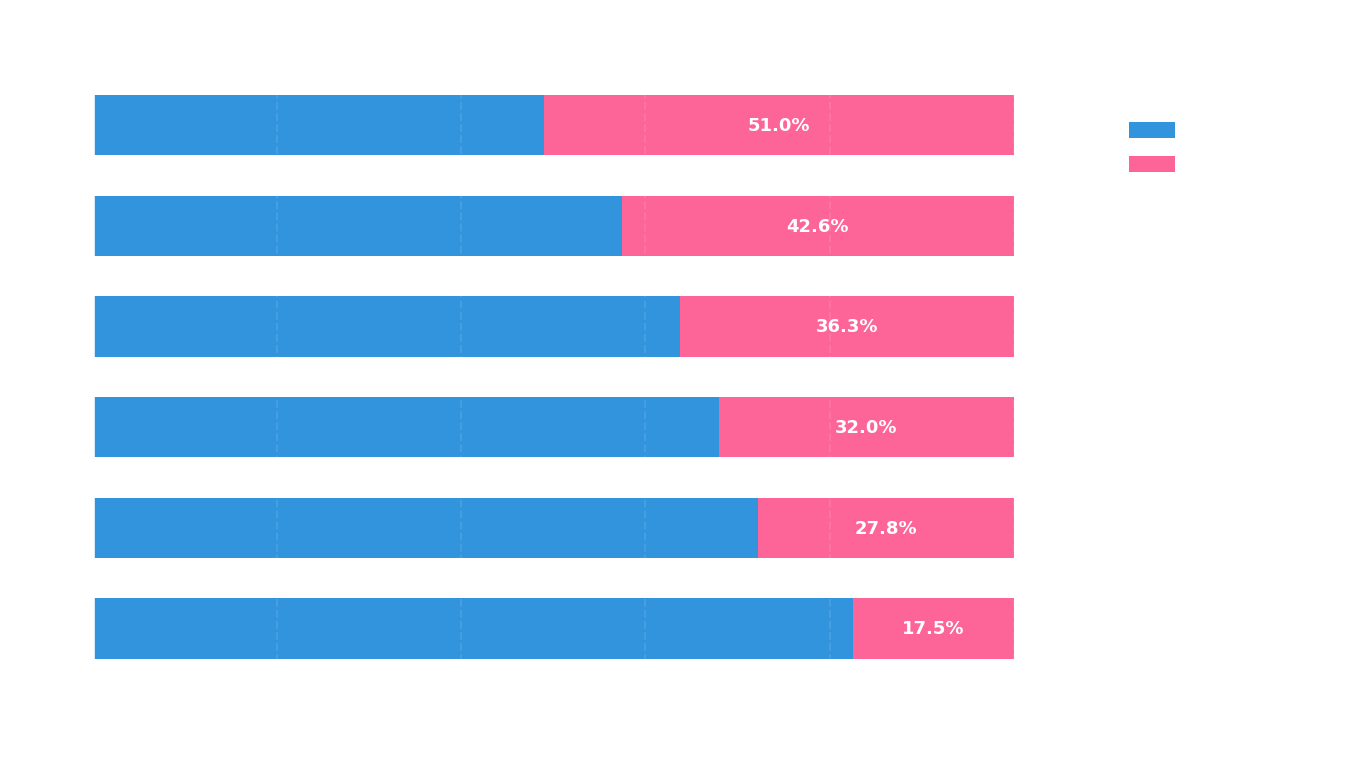

In [109]:
non_college_labels = [
    'Kindergarten/None', 'Elementary', 
    'Some High School', 'High School Grad'
]

df_race_edu = df_eda[df_eda['_IMPRACE'].isin(target_races)].copy()

df_race_edu['EDU_BIN'] = df_race_edu['EDUCA'].apply(
    lambda x: 'Non-College' if x in non_college_labels else 'College Grad'
)

dist_edu_bin = pd.crosstab(df_race_edu['_IMPRACE'], df_race_edu['EDU_BIN'], normalize='index') * 100
dist_edu_bin = dist_edu_bin.sort_values('Non-College', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))

dist_edu_bin.plot(kind='barh', stacked=True, ax=ax, color=neon_colors[[3, 1]], width=0.6)

for i, (race, row) in enumerate(dist_edu_bin.iterrows()):
    val = row['Non-College']
    ax.text(100 - (val/2), i, f'{val:.1f}%', 
            va='center', ha='center', color='#FFFFFF', fontweight='bold', fontsize=13)

plt.title('Disparitas Pendidikan: Proporsi Pendidikan Non-Sarjana per Ras', 
          fontsize=18, weight='bold', color='#FFFFFF', pad=30)
plt.xlabel('Proporsi Populasi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(
    title='Tingkat Pendidikan', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=False, 
    labelcolor='#FFFFFF', 
    title_fontsize=12
)

ax.grid(True, axis='x', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.show()

/tmp/ipykernel_17503/4188168093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_17503/4188168093.py:5: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.boxplot(
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/dio/Me/python_env/learn_pytorch/lib/python3.12/

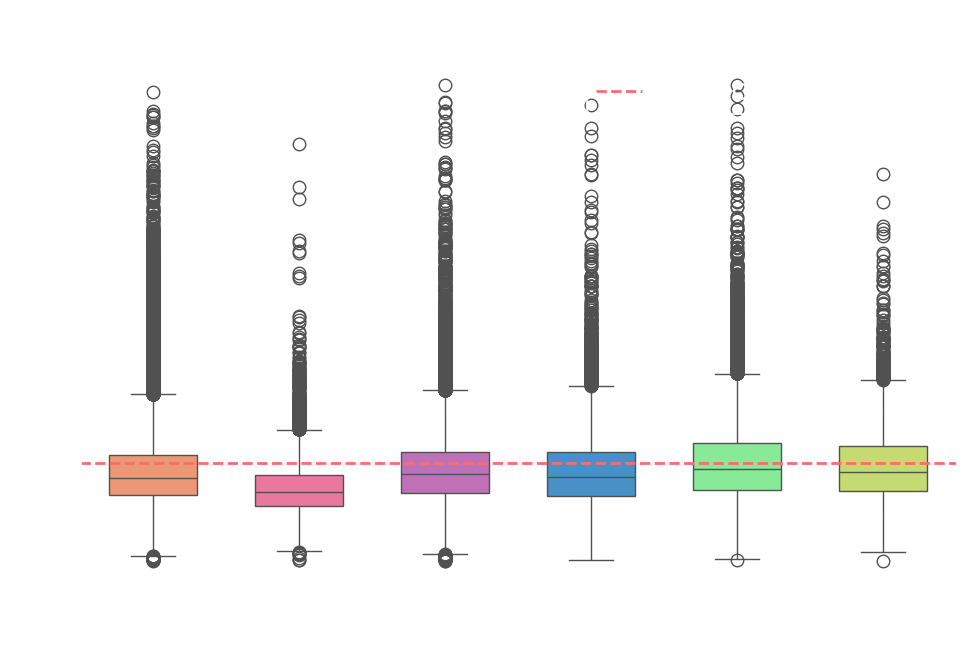

In [111]:
df_race_bmi = df_eda[df_eda['_IMPRACE'].isin(target_races)].copy()

fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=df_race_bmi,
    x='_IMPRACE',
    y='_BMI5',
    order=target_races,
    palette=neon_colors,
    width=0.6,
    ax=ax
)

plt.axhline(y=30, color='#FF6B6B', linestyle='--', linewidth=2, label='Batas Obesitas (BMI 30)')

plt.title('Perbandingan BMI pada Kelompok Ras Berisiko Tinggi', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=25)
plt.xlabel('Kelompok Ras', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('Body Mass Index (BMI)', fontsize=12, weight='bold', color='#FFFFFF')


plt.legend(facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF')

ax.grid(True, axis='y', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/deepdive/deepdive_race_bmi_box_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [112]:
df_eda["EXERANY2"] = df["EXERANY2"].map({
    1: "Yes",
    2: "No"
})

In [113]:
df_eda.dropna(inplace=True)

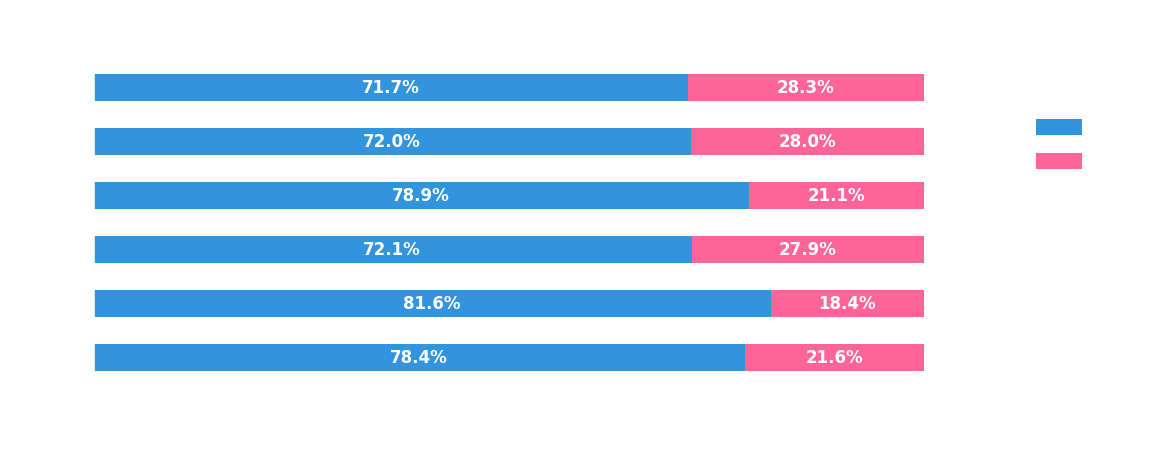

In [118]:
df_race_exer = df_eda[df_eda['_IMPRACE'].isin(target_races)].copy()
dist_race_exer = pd.crosstab(df_race_exer['_IMPRACE'], df_race_exer['EXERANY2'], normalize='index') * 100
dist_race_exer = dist_race_exer.reindex(index=target_races, columns=['Yes', 'No'])

fig, ax = plt.subplots(figsize=(12, 5))

dist_race_exer.plot(kind='barh', stacked=True, ax=ax, color=[neon_colors[3], neon_colors[1]], width=0.5)

for p in ax.patches:
    width = p.get_width()
    if width > 5:
        x = p.get_x() + (width / 2)
        y = p.get_y() + (p.get_height() / 2)
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', 
                    color='#FFFFFF', fontweight='bold', fontsize=12)

plt.title('Aktivitas Fisik: Perbandingan Gaya Hidup pada Kelompok Ras Berisiko', 
          fontsize=16, weight='bold', color='#FFFFFF', pad=25)
plt.xlabel('Proporsi Aktivitas Fisik dalam 30 Hari Terakhir (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(title='Olahraga', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF')


plt.tight_layout()
plt.savefig('./outputs/deepdive/deepdive_race_exercise_ppt.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

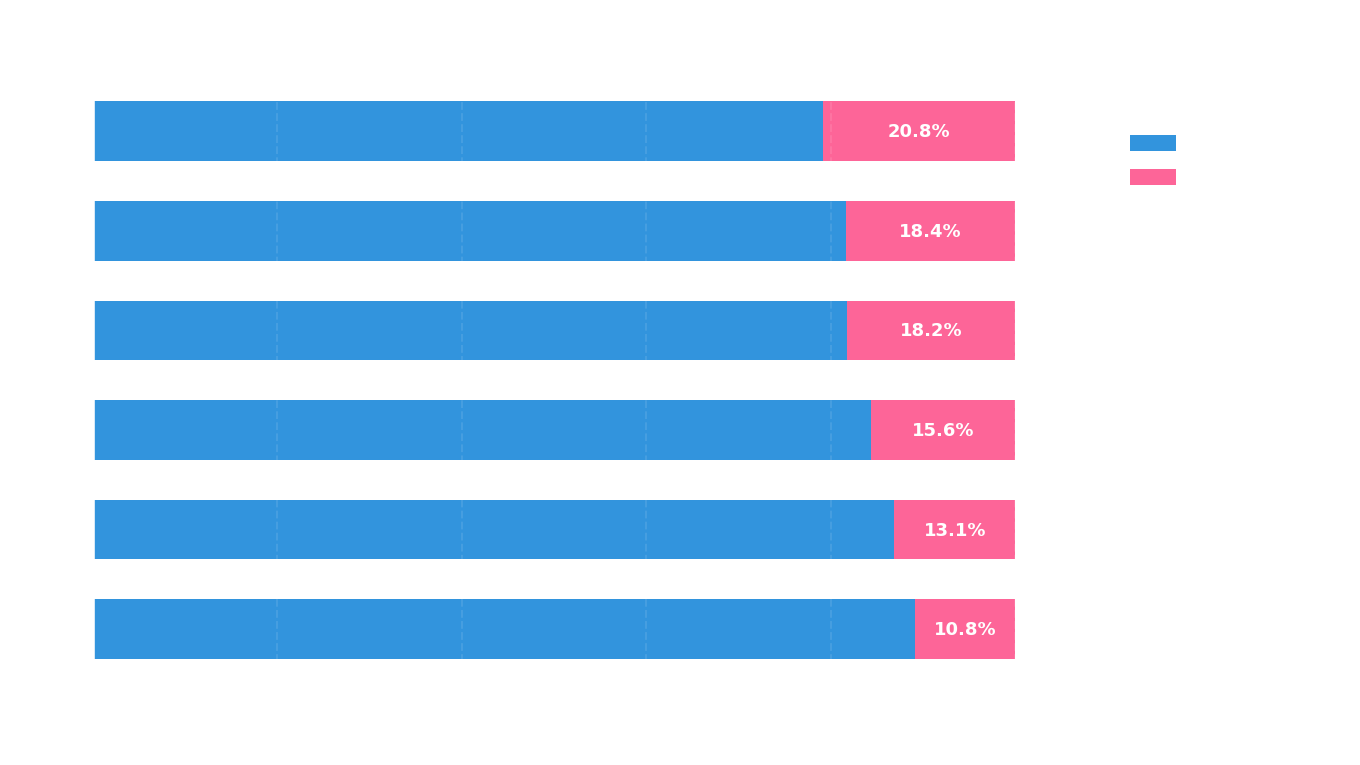

In [133]:
senior_age = ['55-64', ' 65+']

df_race_age['AGE_BIN'] = df_race_age['_AGE_G'].apply(
    lambda x: 'Senior (55+)' if x in senior_age else 'Under 55'
)

dist_age_bin = pd.crosstab(df_race_age['_IMPRACE'], df_race_age['AGE_BIN'], normalize='index') * 100
dist_age_bin = dist_age_bin[['Under 55', 'Senior (55+)']]
dist_age_bin = dist_age_bin.sort_values('Senior (55+)', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))

dist_age_bin.plot(kind='barh', stacked=True, ax=ax, color=neon_colors[[3,1]], width=0.6)

for i, (race, row) in enumerate(dist_age_bin.iterrows()):
    val = row['Senior (55+)']  
    ax.text(100 - (val/2), i, f'{val:.1f}%', 
            va='center', ha='center', color='#FFFFFF', fontweight='bold', fontsize=13)

plt.title('Disparitas Usia: Proporsi Populasi Berisiko Tinggi (55+) per Ras', 
          fontsize=18, weight='bold', color='#FFFFFF', pad=35)
plt.xlabel('Proporsi Populasi (%)', fontsize=12, weight='bold', color='#FFFFFF', labelpad=15)
plt.ylabel('')

plt.legend(title='Kelompok Usia', bbox_to_anchor=(1.05, 1), loc='upper left', 
           facecolor='none', edgecolor='#FFFFFF', labelcolor='#FFFFFF')

ax.grid(True, axis='x', color='#FFFFFF', alpha=0.1, linestyle='--')

plt.tight_layout()
plt.savefig('./outputs/deepdive/deepdive_race_age_binary_55.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [134]:
# TODO Deep dive insights + Business Question conclusions.